# 03: QAOAによる組み合わせ最適化エンジンの構築
## (Quantum Approximate Optimization Algorithm as a Hybrid Engine)

---

## 1. Thesis: 科学的問いと仮説
前回のAQC（断熱量子計算）では、物理的な時間発展を細かく区切る（トロッター分解する）ことで確実に最適解へ導けることを確認しました。しかし、ステップ数 $N$ が大きくなると量子回路が非常に深くなり、現在のノイズの多い量子コンピュータ（NISQ）では実行不可能です。

**問い** : 回路の深さ（ステップ数）を極端に短く制限した状態でも、古典コンピュータによる「自己学習（パラメータ最適化）」を組み合わせることで、AQCに迫る精度で最適解を導き出せるのではないか？

**仮説** : トロッター分解における各ステップの回転角（$A(t), B(t)$ に依存する固定値）を、自由に調整可能なパラメータ $\gamma, \beta$ へと置き換えた **QAOA (Quantum Approximate Optimization Algorithm)** を用いる。そして古典オプティマイザループによってエネルギー（期待値）が最小となる $\gamma, \beta$ を探索させれば、「浅い回路（少ない $p$）」であっても効率的にMax-Cut問題などの最適解へ収束させることができる。

## 2. Theoretical Background (理論的背景)

QAOAは、AQC（断熱量子計算）の離散化モデルをベースに生まれた、代表的な**変分量子アルゴリズム (VQA)** です。

### 2.1 AQCからQAOAへの飛躍
AQCでは全体の時間 $T$ を $N$ ステップに分割し、「徐々にX回転を弱め、ZZ結合を強める」という固定のスケジュールに従いました。
QAOAでは、この $N$ ステップを **$p$ サブレイヤー（Depth）** と呼び、各レイヤーでの回転角を時間依存の固定値ではなく、古典的に最適化すべき「変数」として扱います。

$$
|\psi(\vec{\gamma}, \vec{\beta})\rangle = e^{-i \beta_p H_M} e^{-i \gamma_p H_C} \dots e^{-i \beta_1 H_M} e^{-i \gamma_1 H_C} |+\rangle^{\otimes n}
$$

### 2.2 パラメータ化された2つのハミルトニアン
1. **コストハミルトニアン ($H_C$) とパラメータ $\gamma$**
   解きたい最適化問題を表すZベースの相互作用です。（AQCの $H_{target}$ に相当）
   パラメータ $\gamma_k$ に応じて位相を回転させます。
2. **ミキシングハミルトニアン ($H_M$) とパラメータ $\beta$**
   すべての量子ビットに対するX回転の和です。（AQCの $H_{start}$ に相当）
   パラメータ $\beta_k$ に応じて確率振幅を混ぜ合わせ、局所解からの脱出を促します。

### 2.3 古典・量子ハイブリッド最適化ループ
QAOAは以下のループを繰り返すことで機能します：
1. **[Quantum]** 現在のパラメータ $(\gamma, \beta)$ で回路を実行し、状態を測定する。
2. **[Classical]** 測定結果から「目的関数の期待値（コスト）」を計算する。
3. **[Classical]** 古典最適化アルゴリズム（COBYLAなど）を使い、コストが下がるような新しい $(\gamma, \beta)$ を推測・更新する。
4. 1〜3を収束するまで繰り返す。


## 3. Implementation (実装)

Qiskitの標準機能を活用し、QAOAのハイブリッドループ全体をカプセル化した関数を実装します。
対象問題はAQCの時と同じく、3ノードの直線グラフ `0 -- 1 -- 2` のMax-Cut問題です。


## 4. Visualization & Analysis (可視化と解析)

まず古典オプティマイザ(COBYLA)を用いて量子回路のパラメータ探索ループを回し、最適化完了後にそのパラメータを用いて最終的な状態をサンプリング・可視化します。


=== QAOA ハイブリッド最適化エンジン (Max-Cut問題) ===
グラフ構造: 0 -- 1 -- 2 (ノード数: 3)
QAOAレイヤー数(p): 1, 最大最適化ループ回数: 50

[最適化ループ開始] 古典オプティマイザ(COBYLA)が最適なgamma, betaを探索中...
[最適化完了]
最適なパラメータ: [2.70882767 1.9315519 ]
最小エネルギー評価値: -1.628

--- 最終測定結果 (Optimal Parameters) ---
状態 |101⟩:  33.3% -> カット数: 2
状態 |010⟩:  30.1% -> カット数: 2
状態 |100⟩:   9.6% -> カット数: 1
状態 |011⟩:   9.2% -> カット数: 1
状態 |001⟩:   9.2% -> カット数: 1


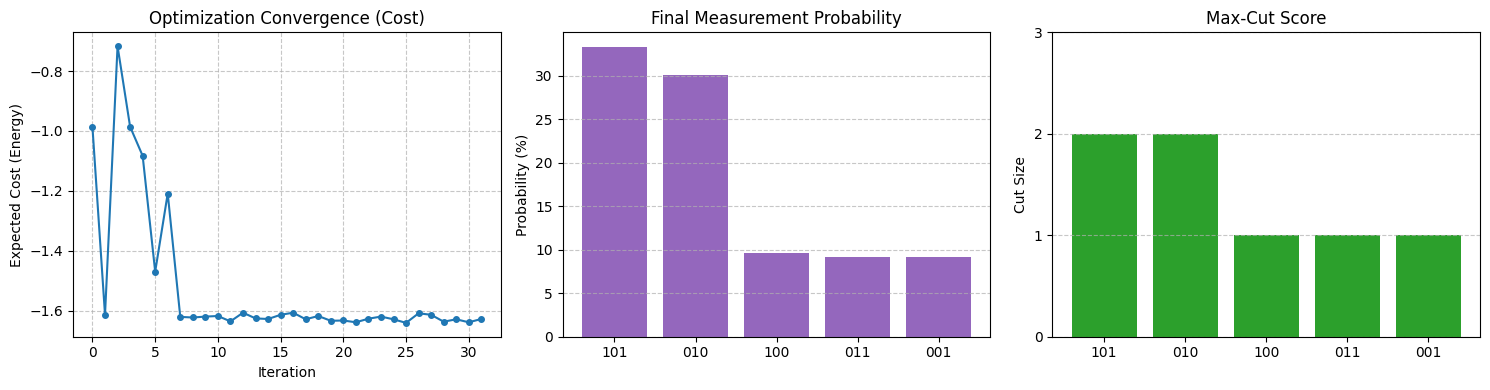

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from scipy.optimize import minimize

def run_qaoa_hybrid_optimization(p: int = 1, maxiter: int = 50) -> None:
    """QAOA（量子近似最適化アルゴリズム）の古典・量子ハイブリッドループを実行します。
    
    Args:
        p (int): QAOA回路のレイヤー数（深さ）。大きいほど表現力が増しますが、最適化が難しくなります。
        maxiter (int): 古典オプティマイザ(COBYLA)の最大ループ反復回数。
    """
    print("\n=== QAOA ハイブリッド最適化エンジン (Max-Cut問題) ===")
    num_qubits = 3
    edges = [(0, 1), (1, 2)]
    print(f"グラフ構造: 0 -- 1 -- 2 (ノード数: {num_qubits})")
    print(f"QAOAレイヤー数(p): {p}, 最大最適化ループ回数: {maxiter}")

    sim = AerSimulator()
    cost_history = []  # 最適化の過程を記録するリスト

    # 1. QAOA回路を構築する関数
    def create_qaoa_circuit(gamma, beta):
        qc = QuantumCircuit(num_qubits)
        qc.h(range(num_qubits)) # 初期状態 |+>
        
        for k in range(p):
            # Cost Hamiltonian (ZZ結合による回転: RZZ)
            # Qiskitでは cx -> rz -> cx でRZZを実装
            for i, j in edges:
                qc.cx(i, j)
                qc.rz(2 * gamma[k], j)
                qc.cx(i, j)
            
            # Mixing Hamiltonian (X回転: RX)
            for i in range(num_qubits):
                qc.rx(2 * beta[k], i)
                
        qc.measure_all()
        return qc

    # 2. 状態（ビット列）からMax-Cutのスコア(カット数)とコストを計算する関数
    def compute_maxcut_cost(counts, shots):
        avg_cost = 0
        for bitstring, count in counts.items():
            cut_size = 0
            bits = bitstring[::-1] # Qiskitのビット順序を補正
            for i, j in edges:
                if bits[i] != bits[j]:
                    cut_size += 1
            
            # 最適化アルゴリズムは「最小化」を行うため、
            # カット数を負にしてコスト(エネルギー)とみなす
            energy = -cut_size 
            prob = count / shots
            avg_cost += energy * prob
        return avg_cost

    # 3. 古典オプティマイザから呼ばれる「目的関数（コスト計算）」
    def objective_function(params):
        gamma = params[:p]
        beta = params[p:]
        
        qc = create_qaoa_circuit(gamma, beta)
        qc_compiled = transpile(qc, sim)
        
        shots = 1000
        result = sim.run(qc_compiled, shots=shots).result()
        counts = result.get_counts()
        
        cost = compute_maxcut_cost(counts, shots)
        cost_history.append(cost)
        return cost

    # --- 最適化の実行 (古典・量子ハイブリッドループ) ---
    print("\n[最適化ループ開始] 古典オプティマイザ(COBYLA)が最適なgamma, betaを探索中...")
    
    # パラメータの初期推定値（ランダムに開始）
    init_params = np.random.rand(2 * p) * np.pi 
    
    result = minimize(
        objective_function, 
        init_params, 
        method='COBYLA', 
        options={'maxiter': maxiter, 'disp': False}
    )
    
    print("[最適化完了]")
    print(f"最適なパラメータ: {result.x}")
    print(f"最小エネルギー評価値: {result.fun:.3f}")

    # --- 最適なパラメータで最終確認（実験） ---
    opt_gamma = result.x[:p]
    opt_beta = result.x[p:]
    final_qc = create_qaoa_circuit(opt_gamma, opt_beta)
    final_qc_compiled = transpile(final_qc, sim)
    final_counts = sim.run(final_qc_compiled, shots=1000).result().get_counts()

    # 最大の確率を持つ状態を抽出して表示
    print("\n--- 最終測定結果 (Optimal Parameters) ---")
    sorted_counts = dict(sorted(final_counts.items(), key=lambda x: x[1], reverse=True))
    
    states, probs, cut_sizes = [], [], []
    for i, (state, count) in enumerate(sorted_counts.items()):
        if i >= 5: break
        prob = count / 1000 * 100
        
        cut_size = 0
        bits = state[::-1]
        for u, v in edges:
            if bits[u] != bits[v]: cut_size += 1
                
        states.append(state)
        probs.append(prob)
        cut_sizes.append(cut_size)
        print(f"状態 |{state}⟩: {prob:5.1f}% -> カット数: {cut_size}")

    # --- 結果の可視化 ---
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))
    
    # 1. コストの収束履歴
    ax1.plot(cost_history, marker='o', color='#1f77b4', markersize=4)
    ax1.set_title("Optimization Convergence (Cost)")
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Expected Cost (Energy)")
    ax1.grid(True, linestyle='--', alpha=0.7)

    # 2. 確率分布
    ax2.bar(states, probs, color='#9467bd')
    ax2.set_title("Final Measurement Probability")
    ax2.set_ylabel("Probability (%)")
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    
    # 3. カット数スコア
    ax3.bar(states, cut_sizes, color='#2ca02c')
    ax3.set_title("Max-Cut Score")
    ax3.set_ylabel("Cut Size")
    ax3.set_yticks(range(0, 4))
    ax3.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# レイヤー数p=1、最大イテレーション50で実行
run_qaoa_hybrid_optimization(p=1, maxiter=50)


## 5. Conclusion & Future Work (結論と展望)

### 結論
本ノートブックでは、AQCの固定化された時間依存スケジュールを、パラメータ化された浅い量子回路（QAOA）へと変換し、古典オプティマイザと連携させて最適化問題を解くエンジンを構築しました。

1. **浅い回路による最適化の成功** : $p=1$ という極めて浅い回路（トロッター分解1ステップ相当）であっても、古典コンピュータ側で最適な角度（$\gamma, \beta$）を見つけ出すことで、最適解である `010` と `101` の出現確率を効果的に増幅できることが確認できました。

2. **ハイブリッドループの有効性** : 量子側は「状態のサンプリング（期待値の評価）」のみに専念し、重たいパラメータ探索の計算は古典側（COBYLA等）に任せるアーキテクチャは、現在のNISQデバイスにおいて極めて現実的かつ強力なアプローチです。

### 展望
- **レイヤー数 $p$ のスケーリング評価** : 理論上は $p \to \infty$ でAQCと一致し、精度が向上します。しかし、$p$ を増やすと最適化すべきパラメータ数（$2p$ 個）が増大し、古典オプティマイザが局所解に陥りやすくなる（Barren Plateaus問題など）というトレードオフが生じます。最適な $p$ の選定アルゴリズムの探求が必要です。

- **ノイズ環境下での挙動確認** : 現在は理想的なシミュレータを使用していますが、実機（ノイズモデル）を通した際に、ハイブリッドループがどこまで機能するか（ノイズ耐性）を検証することが実用化への次のステップとなります。
